In [24]:
import ee
import geemap
import pandas as pd
ee.Authenticate(auth_mode='notebook')
ee.Initialize()

# Inicializacion y Area de Interes (ROI)

Primero, definimos el polígono exacto de la laguna. He ajustado las coordenadas al estándar [Longitud, Latitud].

In [25]:
import matplotlib.pyplot as plt

roi = ee.Geometry.Polygon([
    [
        [-75.476052, 10.517524], # Longitud primero, luego Latitud
        [-75.476117, 10.518747],
        [-75.473158,10.519223 ],
        [-75.470516, 10.525108],
        [-75.469572, 10.524876],
        [-75.471686, 10.518916],
        [-75.468394, 10.517219],
        [-75.468952, 10.516459],
        [-75.476052, 10.517524]  # Cierre del polígono
    ]
])

# PASO A (Sentinel-2)

contorno estable de la laguna (la mascara_fija) usando el promedio de un año. Esto se hace una sola vez.

## Filtro espacial estático

Para no contar los árboles de los patios de las casas ni edificios, creamos una "plantilla" que solo deje pasar la señal de la laguna.

Para eliminar el ruido de la tierra firme

- Aqui aplicamos el **MNDWI (Modified Normalized Difference Water Index)**
- Conn la siguiente linea de codigo estamos binarizando el mapa para tener solo los que son de agua respecto a un umbral que es el que acabamos de definir
```
return mndwi.gt(0.026)
```



In [26]:
def obtener_mascara_laguna(roi):
    imagen_base = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
                  .filterBounds(roi)
                  .filterDate('2025-01-01', '2025-12-31')
                  .median())

    # Índice MNDWI para detectar agua
    mndwi = imagen_base.normalizedDifference(['B3', 'B11'])
    return mndwi.gt(0.026) # 1 donde hay agua, 0 donde hay tierra

mascara_fija = obtener_mascara_laguna(roi)

In [27]:
# 1. Crear el mapa centrado en tu ROI
Map = geemap.Map()
Map.centerObject(roi, 16)

# 2. Visualizar la máscara fija
# Los píxeles con valor 1 (agua) se verán azules, los de valor 0 (tierra) serán transparentes
Map.addLayer(mascara_fija.selfMask(), {'palette': ['blue']}, 'Máscara de Agua (Fija)')

# 3. (Opcional) Visualizar el ROI para comparar
Map.addLayer(roi, {'color': 'red'}, 'Polígono ROI', False) # El False lo deja desactivado por defecto

Map

Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

In [41]:
area_agua_m2 = mascara_fija.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10, # Resolución de 10 metros por píxel
    maxPixels=1e9
).get('nd').getInfo()

print(f"El área detectada de agua dentro del polígono ROI es: {area_agua_m2:.2f} m²")

El área detectada de agua dentro del polígono ROI es: 93109.41 m²


## Proceso de todas las imagenes

In [53]:
def procesar_fecha(image):
    # 'updateMask' hace que todo lo que NO sea laguna se vuelva invisible
    img_recortada = image.clip(roi).updateMask(mascara_fija)
    vegetacion = img_recortada.select('VV').gt(-15) # Ahora que la imagen está "limpia", detectamos la vegetación
    #Calculamos el área (solo sobre los píxeles que sobrevivieron a la máscara)
    area = vegetacion.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).get('VV')

    return ee.Feature(None, {'fecha': image.date().format('yyyy-MM-dd'), 'area_m2': area})

- Ahora hasta este punto ya tenemos el ROI y el umbral y la tecnica o filtro que vamos a aplicar que es el MNDWI y usamos para este el Sentinel-2 ya que este tiene las bandas opticas (Vende e infrarrojo) que son las que lo permiten calcular, es el mejor indice para diferenciar agua de tierra

- Ahora la pregunta es, ¿Y si usamos el sentinel-2 para eso, lo deberiamos usar para medir vegetacion todo el año?, En cartagena hay muchas nubes, si usamos eso mismo en junio o septiembre, no veremos laguna, sino nues blancas y la serie temporal tendra muchos huecos, por lo que la tecnica, será aplicar la mascara del S2 al Sentinel-1

- ¿Como aplicamos la mascara del S2 al S1?, Aunque la mascara se creo con datos del S2, mascara-fija es simplemente una imagen binarizada de 0s y 1s con coordendas geograficas

Cuando se hace esto:


```
img_recortada = image.clip(roi).updateMask(mascara_fija)
```
Si esa **image** pertenece al S1, Earth Engine simplemente superpone el molde de S2 sobre el radar de S1

---
## ¿Que se logra con esto?

Se logra tener una precision visual del S2 (para saber donde esta el agua) combinada con la capacidad de ver a traves de las nubes del S1 (para medir vegetacion cada 6 o 12 dias sin falta)

---



# PASO B (Sentinel-1)

Tomamos la colección de imágenes de Radar de 2025.

In [54]:
fecha_inicio = '2025-01-01'
fecha_fin = '2025-12-31'

In [55]:
# Filtramos por nuestra zona (roi), por fecha y por modo de instrumento
coleccion_radar = (ee.ImageCollection("COPERNICUS/S1_GRD")
                  .filterBounds(roi)
                  .filterDate(fecha_inicio, fecha_fin)
                  .filter(ee.Filter.eq('instrumentMode', 'IW'))
                  .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')))

In [56]:
coleccion_radar

In [57]:
#Mapear la función sobre toda la colección (esto es: aplicarlo a todas)
resultados = coleccion_radar.map(procesar_fecha).getInfo()['features']

## Visualizacion Ejemplo

In [48]:
imagen_radar = ee.Image(coleccion_radar.first())
imagen_solo_laguna = imagen_radar.clip(roi).updateMask(mascara_fija)
capa_vegetacion = imagen_solo_laguna.select('VV').gt(-15)

Map = geemap.Map()
Map.centerObject(roi, 16)

Map.addLayer(mascara_fija.selfMask(), {'palette': ['#000044']}, 'Espejo de Agua')
Map.addLayer(capa_vegetacion.selfMask(), {'palette': ['#00FF00']}, 'Vegetación (Solo dentro de máscara)')
Map.addLayer(roi, {'color': 'red'}, 'Polígono ROI', False)

Map

Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

# PASO C (Finiquitando...)

Hacer el wrangling de los datos y formacion del dataset

In [59]:
resultados

[{'type': 'Feature',
  'geometry': None,
  'id': 'S1A_IW_GRDH_1SDV_20250102T104949_20250102T105018_057264_070B67_BA28',
  'properties': {'area_m2': 17534.829330115223, 'fecha': '2025-01-02'}},
 {'type': 'Feature',
  'geometry': None,
  'id': 'S1A_IW_GRDH_1SDV_20250102T231600_20250102T231625_057272_070BAE_66A5',
  'properties': {'area_m2': 14032.649974179734, 'fecha': '2025-01-02'}},
 {'type': 'Feature',
  'geometry': None,
  'id': 'S1A_IW_GRDH_1SDV_20250114T104948_20250114T105017_057439_071257_0DB5',
  'properties': {'area_m2': 16552.930998110303, 'fecha': '2025-01-14'}},
 {'type': 'Feature',
  'geometry': None,
  'id': 'S1A_IW_GRDH_1SDV_20250114T231559_20250114T231624_057447_07129D_0158',
  'properties': {'area_m2': 22429.00879836737, 'fecha': '2025-01-14'}},
 {'type': 'Feature',
  'geometry': None,
  'id': 'S1A_IW_GRDH_1SDV_20250126T104948_20250126T105017_057614_07194A_B7C0',
  'properties': {'area_m2': 17667.082786051433, 'fecha': '2025-01-26'}},
 {'type': 'Feature',
  'geometry': N

In [60]:
df = pd.DataFrame([f['properties'] for f in resultados])
df

,area_m2,fecha
0,17534.829330,2025-01-02
1,14032.649974,2025-01-02
2,16552.930998,2025-01-14
3,22429.008798,2025-01-14
4,17667.082786,2025-01-26
...,...,...
98,20625.329515,2025-11-28
99,18400.952644,2025-12-10
100,19324.769044,2025-12-10
101,15987.810245,2025-12-22


In [61]:
df = df.rename(columns={'area_m2': 'area_m2_vegetacion'})
df['fecha'] = pd.to_datetime(df['fecha'])
area_total_laguna = 93109.41
df['ratio_vegetacion_agua'] = (df['area_m2_vegetacion'] / area_total_laguna)
df_ts = df.groupby('fecha').mean().sort_index()

In [62]:
df_ts

,area_m2_vegetacion,ratio_vegetacion_agua
fecha,,
2025-01-02,15783.739652,0.169518
2025-01-14,19490.969898,0.209334
2025-01-26,17162.594861,0.184327
2025-02-07,16898.086641,0.181486
2025-02-19,14474.150935,0.155453
2025-03-03,16120.850883,0.173139
2025-03-15,14474.740988,0.155459
2025-03-27,16025.682772,0.172117
2025-04-02,11029.270702,0.118455


### Visualizacion serie de tiempo

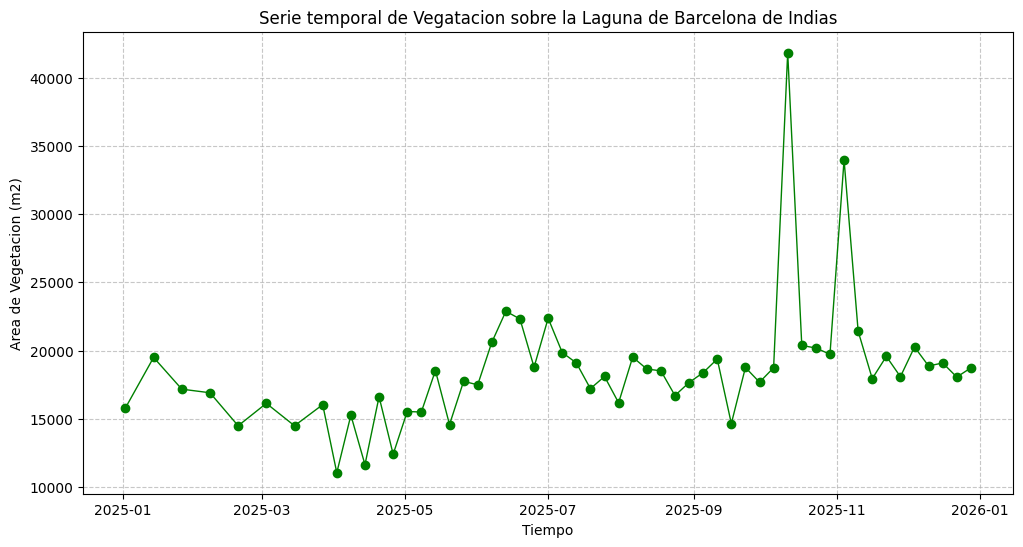

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts.index, df_ts['area_m2_vegetacion'], color='green', linewidth=1,marker="o")
plt.title('Serie temporal de Vegatacion sobre la Laguna de Barcelona de Indias')
plt.xlabel('Tiempo')
plt.ylabel('Area de Vegetacion (m2)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

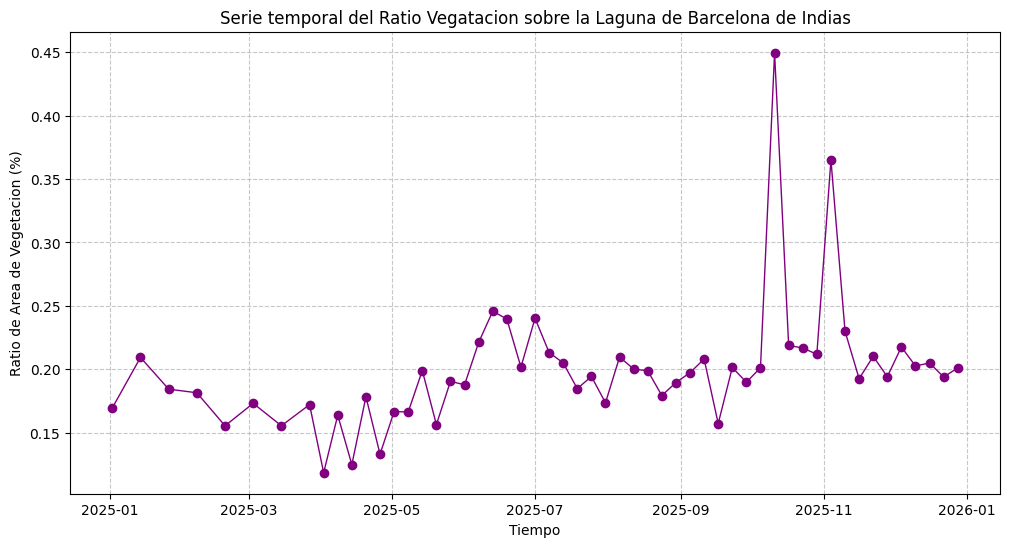

In [66]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts.index, df_ts['ratio_vegetacion_agua'], color='purple', linewidth=1,marker="o")
plt.title('Serie temporal del Ratio Vegatacion sobre la Laguna de Barcelona de Indias')
plt.xlabel('Tiempo')
plt.ylabel('Ratio de Area de Vegetacion (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()